# Sample 7 — Deep dive: real GPT-2 inference with 🤗 `transformers`

Every previous notebook built something from scratch — a tokenizer, an embedding table,
attention, a full transformer block, and finally a trained mini-GPT. This notebook sets that code
aside and loads a **real pretrained model**: `distilgpt2`, a distilled version of GPT-2 with the
same architecture family and tokenizer, via HuggingFace's `transformers` library.

The goal is to connect every concept from `sample-1`–`sample-6` to its production counterpart:
same ideas, real scale, a library instead of hand-rolled code.

*(This downloads ~330MB of model weights the first time it runs — needs internet access.)*


## 1. The real tokenizer, vs. `sample-1`'s hand-built one

`sample-1` built a word-level tokenizer and hit the out-of-vocabulary problem immediately: any
word not seen during "training" had no id. GPT-2's tokenizer uses **byte-pair encoding (BPE)**: a
fixed vocabulary of ~50k subword pieces, learned so that common words get a single token and rare
or unseen words get split into a handful of familiar pieces — so there is no OOV problem, ever.

In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

MODEL_NAME = "distilgpt2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"vocab size: {tokenizer.vocab_size:,}  (sample-1's word-level vocab: 6 words)")


vocab size: 50,257  (sample-1's word-level vocab: 6 words)


In [2]:
sentence = "the cat sat on the mat"
ids = tokenizer.encode(sentence)
tokens = tokenizer.convert_ids_to_tokens(ids)

print("ids:   ", ids)
print("tokens:", tokens)
print("decoded:", tokenizer.decode(ids))


ids:    [1169, 3797, 3332, 319, 262, 2603]
tokens: ['the', 'Ġcat', 'Ġsat', 'Ġon', 'Ġthe', 'Ġmat']
decoded: the cat sat on the mat


Notice the `Ġ` prefix on most tokens — GPT-2's tokenizer works on raw bytes, and `Ġ` marks "a
space precedes this token" (so it can tell `"cat"` at the start of text apart from `" cat"` mid
-sentence, and reconstruct spacing exactly on decode). Now the OOV test that broke `sample-1`'s
tokenizer:

In [3]:
unseen_word = "supercalifragilisticexpialidocious"
ids = tokenizer.encode(unseen_word)
tokens = tokenizer.convert_ids_to_tokens(ids)

print(f"'{unseen_word}' was never a single token in training, but BPE still handles it:")
print("tokens:", tokens)
print("decoded back:", tokenizer.decode(ids))
print(f"\n{len(tokens)} subword pieces instead of 1 unknown-word error — this is the fix "
      f"sample-1 previewed.")


'supercalifragilisticexpialidocious' was never a single token in training, but BPE still handles it:
tokens: ['super', 'cal', 'if', 'rag', 'il', 'ist', 'ice', 'xp', 'ial', 'id', 'ocious']
decoded back: supercalifragilisticexpialidocious

11 subword pieces instead of 1 unknown-word error — this is the fix sample-1 previewed.


## 2. The real architecture, vs. `sample-6`'s mini-GPT

Same components as `sample-6`'s `MiniGPT` — token embedding, positional embedding, a stack of
causal transformer blocks, a final projection to vocabulary logits — just far larger.

In [4]:
# attn_implementation="eager" is needed to get attention weights back later (output_attentions=True) —
# the faster "sdpa" backend that's the default doesn't compute/return them.
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, attn_implementation="eager")
model.eval()
cfg = model.config

n_params = sum(p.numel() for p in model.parameters())
print(f"{MODEL_NAME} config:")
print(f"  layers (n_layer):        {cfg.n_layer}")
print(f"  attention heads (n_head): {cfg.n_head}")
print(f"  embedding dim (n_embd):   {cfg.n_embd}")
print(f"  max context (n_positions):{cfg.n_positions}")
print(f"  vocab size:               {cfg.vocab_size:,}")
print(f"  total parameters:         {n_params:,}")
print(f"\nsample-6's MiniGPT, for comparison: 3 layers, 4 heads, d_model=64, ~157K parameters")
print(f"{MODEL_NAME} has ~{n_params / 157_401:,.0f}x as many parameters")


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

distilgpt2 config:
  layers (n_layer):        6
  attention heads (n_head): 12
  embedding dim (n_embd):   768
  max context (n_positions):1024
  vocab size:               50,257
  total parameters:         81,912,576

sample-6's MiniGPT, for comparison: 3 layers, 4 heads, d_model=64, ~157K parameters
distilgpt2 has ~520x as many parameters


## 3. Real attention weights

`sample-6`'s `MultiHeadAttention` returned its softmax weights for inspection; GPT-2 can do the
same via `output_attentions=True`. Let's run one forward pass and look at what an actual trained
attention head focuses on.

In [5]:
prompt = "The cat sat on the mat because it was tired"
inputs = tokenizer(prompt, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs, output_attentions=True)

attentions = outputs.attentions  # tuple of length n_layer, each (batch, n_head, seq, seq)
print(f"{len(attentions)} layers, each of shape {tuple(attentions[0].shape)}  (batch, heads, seq, seq)")

tokens = [t.replace("\u0120", " ").strip() or "·" for t in tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])]


6 layers, each of shape (1, 12, 10, 10)  (batch, heads, seq, seq)


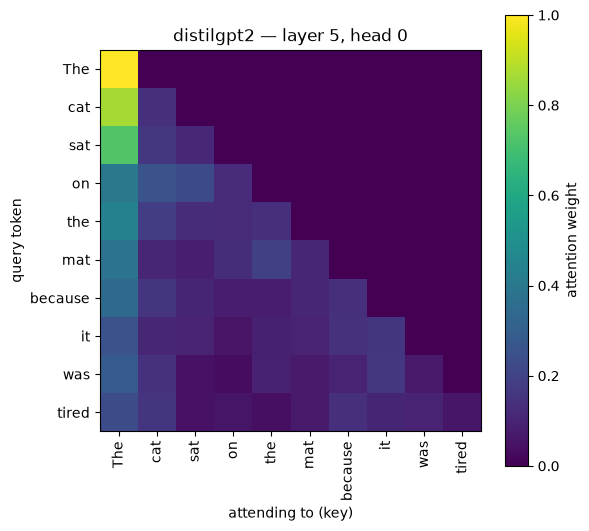

In [6]:
import matplotlib.pyplot as plt

layer, head = cfg.n_layer - 1, 0  # last layer, first head
weights = attentions[layer][0, head].numpy()

fig, ax = plt.subplots(figsize=(6, 5.5))
im = ax.imshow(weights, cmap="viridis", vmin=0, vmax=weights.max())
ax.set_xticks(range(len(tokens))); ax.set_xticklabels(tokens, rotation=90)
ax.set_yticks(range(len(tokens))); ax.set_yticklabels(tokens)
ax.set_xlabel("attending to (key)")
ax.set_ylabel("query token")
ax.set_title(f"{MODEL_NAME} — layer {layer}, head {head}")
fig.colorbar(im, ax=ax, label="attention weight")
plt.tight_layout()
plt.show()


Same lower-triangular structure as `sample-5`/`sample-6`'s causal mask — a real trained model
still obeys "no attending to the future" — but now the *pattern within* that triangle reflects
something the model actually learned from data, not random initialization.

## 4. Generation strategies, via `.generate()`

`sample-6` hand-rolled greedy / temperature / top-k decoding in a Python loop. HuggingFace's
`.generate()` implements the same ideas (plus more, like beam search and top-p / nucleus
sampling) as a single call — internally using a **KV cache** by default (`use_cache=True`), the
optimization `sample-6` demonstrated but didn't implement.

In [7]:
prompt = "Once upon a time"
inputs = tokenizer(prompt, return_tensors="pt")
gen_kwargs = dict(max_new_tokens=30, pad_token_id=tokenizer.eos_token_id)

def show(label, **kwargs):
    torch.manual_seed(0)
    out = model.generate(**inputs, **gen_kwargs, **kwargs)
    text = tokenizer.decode(out[0], skip_special_tokens=True)
    print(f"{label}:\n{text}\n")

show("GREEDY", do_sample=False)
show("TEMPERATURE SAMPLING (T=0.8)", do_sample=True, temperature=0.8, top_k=0)
show("TOP-K SAMPLING (k=50, T=0.8)", do_sample=True, temperature=0.8, top_k=50)
show("TOP-P / NUCLEUS SAMPLING (p=0.9, T=0.8)", do_sample=True, temperature=0.8, top_p=0.9, top_k=0)
show("BEAM SEARCH (5 beams)", do_sample=False, num_beams=5, no_repeat_ngram_size=2)


GREEDY:
Once upon a time of war, the United States was the only country in the world to have a military presence. The United States was the only country in the world to



TEMPERATURE SAMPLING (T=0.8):
Once upon a time where we wanted to have stories that helped shape the story, the story was quite clear and fantastic. One of the most important pieces she‹ve



TOP-K SAMPLING (k=50, T=0.8):
Once upon a time where we wanted to have a meeting, we didn't want the room to be full of new stuff that we were going to be working on. We



TOP-P / NUCLEUS SAMPLING (p=0.9, T=0.8):
Once upon a time, when the world was plunged into chaos, the world had the illusion that the true Emperor would stand still.



Thus, a change



BEAM SEARCH (5 beams):
Once upon a time when the world was in a state of chaos and chaos, it was time to take a step back and look back at the past.

The



A few things to notice, all direct analogues of `sample-6`:

- **Greedy** is deterministic and can loop or get stuck in generic phrasing — same failure mode
  as `sample-6`'s greedy output.
- **Sampling** strategies (temperature, top-k, top-p) introduce variety at the cost of
  determinism, exactly like `sample-6`'s temperature/top-k demo — just with a real, coherent
  language model behind them instead of a memorized nursery rhyme.
- **Beam search** (new here — `sample-6` didn't implement it) keeps several candidate
  continuations in parallel and returns the one with the highest overall sequence probability,
  rather than committing to one choice at a time.

## Full picture

Text → **tokenizer** (`sample-1`, then real BPE here) → **embeddings + positional information**
(`sample-2`, then learned embeddings here) → **attention** (`sample-3`/`sample-4`, then real
trained attention here) → **transformer blocks stacked into a full model** (`sample-5`/`sample-6`,
then GPT-2's real architecture here) → **autoregressive generation** (`sample-6`'s hand-rolled
loop, then `.generate()`'s KV-cached version here). Same mechanism throughout, from a 4-token
hand-traced example to a real pretrained language model.